##### top

# Check the inversion effect on a non-linear scale

Proportion scores (aka accuracy, $acc$; or percent correct $P_c$) is a non-linear scale in perceptual tasks that is bounded between [0,1] (or 0 % - 100 %), often also defined in the range [0.5, 1] if we assume there is no bias going in the opposite direction. As this scale is non-linear and corresponds to a cumulatitive (normal-like) function of the underlying signal that we are interested in ($\Phi$), the way to properly answer the question of the magnitude of the inversion effect is to transform the scores using an inverse normal function ($\Phi^{-1}$) to put them on an interval scale before subtracting one from another. Because this is a 2AFC task, we will use the following formulas to obtain $d'$ for each category (upright, inverted) before subtracting them:

$$d'=\sqrt{2}\Phi^{-1}(P_c).$$

For reference and discussion on this matter see [DeCarlo\[2012\]](https://www.sciencedirect.com/science/article/pii/S0022249612000260).


NOTE: The presence of an inversion effect and its strength in our data can be see from the data directly by comparing the accuracy on inverted trials across levels. This accuracy is very similar across levels, meaning that the difference is coming from a boost for the easier upright positions.

RT
--
Response times are another way to detect inversion effects (for early work see e.g., [Haxby \[1999\]](https://www.sciencedirect.com/science/article/pii/S089662730080690X)). Therefore, we look at them here as well.

>However, I’m concerned that this analysis does not take into account the non-interval scale of the accuracy measure (proportion scores). That is, % correct is a non-linear measure, in this case bounded at 50% and 100% (chance is 50%). The % correct measure likely follows a cumulative normal-like curve as a function of the underlying (latent) discriminability signal that we care about. This means that a given change in the measured variable (% correct) at low values near 50% corresponds to a larger change in the underlying discriminability signal than the same observed change in the % correct variable near 75%. Thus, subtracting inverted % correct from upright % correct is not a theoretically sound thing to do: the authors should instead transform the scores using an inverse normal function to put them on an interval scale before subtracting one from another. I am concerned that this would show no difference in the size of the inversion effect between the different levels of perceptual difficulty. One further question: the inversion effect is often measured by looking at reaction time differences between upright and inverted – did the authors try this?


In [1]:
import os, sys
from os.path import join as opj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy.stats import norm, binomtest

# Importing module for functions
functions_modul =  "../Code/functions"
sys.path.insert(0, functions_modul)

# # import all processing and plotting functions
from plot_functions import star_gazing, get_flattened_palette, plot_significance_pairs
from composite_measures_functions import dprime_2afc

path_data = '../Data'
path_datasets = '../Data/datasets'
path_figures = '../Figures'

# load data
df_dataset6 = pd.read_csv(os.path.join(path_datasets, 'FMP_dataset_6.csv'))
df_dataset6["Experiment"] = "dataset_6"
df_dataset6.reset_index(drop=True, inplace=True)

if 'Unnamed: 0' in df_dataset6.columns:
    df_dataset6.drop('Unnamed: 0', inplace=True, axis=1)

# add target location -- if it was the original
df_dataset6["target_loc_simple"] = (df_dataset6["target"].str.contains('-0p.png')).map({True:"target_0", False:"other"})
df_dataset6["target_loc"] = df_dataset6.target.str.split('_').str[-1].str.split('.').str[0].str.split('-').str[-1]


In [2]:
df_dataset6

,inverted,stim1,stim2,target,RT,userID,order,correct_check,difficulty,levels,correct_flt,task,Experiment,target_loc_simple,target_loc
0,True,invert_sharp_CFD-WM-212-097-N_m4018-0p.png,invert_sharp_CFD-WM-212-097-N_m4018-36p.png,invert_sharp_CFD-WM-212-097-N_m4018-0p.png,NaN,s_1079,1,NaN,1,36,NaN,Unfilled Delay,dataset_6,target_0,0p
1,True,invert_sharp_BFD-M-6_m4018-24p.png,invert_sharp_BFD-M-6_m4018-0p.png,invert_sharp_BFD-M-6_m4018-0p.png,3403.800,s_1079,1,True,3,24,1.0,Unfilled Delay,dataset_6,target_0,0p
2,True,invert_sharp_CFD-BF-051-035-N_AF01NES-0p.png,invert_sharp_CFD-BF-051-035-N_AF01NES-24p.png,invert_sharp_CFD-BF-051-035-N_AF01NES-0p.png,2978.440,s_1079,1,True,3,24,1.0,Unfilled Delay,dataset_6,target_0,0p
3,True,invert_sharp_CFD-WM-203-023-N_m4018-0p.png,invert_sharp_CFD-WM-203-023-N_m4018-36p.png,invert_sharp_CFD-WM-203-023-N_m4018-36p.png,NaN,s_1079,1,NaN,1,36,NaN,Unfilled Delay,dataset_6,other,36p
4,True,invert_sharp_CFD-WF-225-101-N_AF01NES-24p.png,invert_sharp_CFD-WF-225-101-N_AF01NES-0p.png,invert_sharp_CFD-WF-225-101-N_AF01NES-24p.png,1473.080,s_1079,1,True,3,24,1.0,Unfilled Delay,dataset_6,other,24p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17035,False,sharp_CFD-BM-216-088-N_m4018-24p.png,sharp_CFD-BM-216-088-N_m4018-0p.png,sharp_CFD-BM-216-088-N_m4018-24p.png,1569.441,s_656,12,False,3,24,0.0,Unfilled Delay,dataset_6,other,24p
17036,False,sharp_London-M-119-03_m4018-0p.png,sharp_London-M-119-03_m4018-36p.png,sharp_London-M-119-03_m4018-0p.png,998.522,s_656,12,True,1,36,1.0,Unfilled Delay,dataset_6,target_0,0p
17037,False,sharp_BFD-M-356_m4018-0p.png,sharp_BFD-M-356_m4018-36p.png,sharp_BFD-M-356_m4018-0p.png,2716.751,s_656,12,True,1,36,1.0,Unfilled Delay,dataset_6,target_0,0p
17038,False,sharp_BFD-F-65_AF01NES-30p.png,sharp_BFD-F-65_AF01NES-0p.png,sharp_BFD-F-65_AF01NES-0p.png,1478.633,s_656,12,True,2,30,1.0,Unfilled Delay,dataset_6,target_0,0p


## Stats - reproduce main article
[top](#top)

In [3]:
# Check with 2 way ANOVA

d_acc = df_dataset6.groupby(["userID","inverted","difficulty"]).correct_flt.mean().reset_index().copy()


aov_acc = pg.anova(data=d_acc, 
               dv='correct_flt', between=['inverted', 'difficulty'],
             detailed=True)

aov_acc['star_gazing'] = aov_acc['p-unc'].apply(star_gazing)

aov_acc#.round(4)

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,inverted,0.705115,1,0.705115,62.570855,2.298898e-14,0.129661,***
1,difficulty,0.455854,2,0.227927,20.225907,4.108387e-09,0.087852,***
2,inverted * difficulty,0.073789,2,0.036895,3.273986,3.882360e-02,0.015351,*
3,Residual,4.733004,420,0.011269,NaN,NaN,NaN,


In [4]:
# Post-hoc pairwise comparisons for inverted
posthoc_inverted_acc = pg.pairwise_tukey(data=d_acc, dv='correct_flt', between='inverted')
posthoc_inverted_acc['star_gazing'] = posthoc_inverted_acc['p-tukey'].apply(star_gazing)
print("Post-hoc comparisons for inverted:")
# print(posthoc_inverted)
display(posthoc_inverted_acc)

# Post-hoc pairwise comparisons for difficulty
posthoc_difficulty_acc = pg.pairwise_tukey(data=d_acc, dv='correct_flt', between='difficulty', effsize='cohen')
posthoc_difficulty_acc['star_gazing'] = posthoc_difficulty_acc['p-tukey'].apply(star_gazing)
print("\nPost-hoc comparisons for difficulty:")
# print(posthoc_difficulty_acc)
posthoc_difficulty_acc

Post-hoc comparisons for inverted:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,star_gazing
0,False,True,0.71777,0.636402,0.081368,0.010796,7.53721,4.444223e-13,0.729065,***



Post-hoc comparisons for difficulty:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,1,2,0.720120,0.670273,0.049847,0.013547,3.679474,7.700502e-04,0.412921,***
1,1,3,0.720120,0.640866,0.079254,0.013547,5.850195,2.950112e-08,0.691503,***
2,2,3,0.670273,0.640866,0.029407,0.013547,2.170721,7.744354e-02,0.275630,


## Convert to another scale
[top](#top)

* https://www.birmingham.ac.uk/Documents/college-les/psych/vision-laboratory/sdtintro.pdf
* https://stats.stackexchange.com/questions/672408/two-approaches-to-go-from-2afc-accuracy-to-d-how-do-they-differ-and-which-sho
* https://www.columbia.edu/%7Eld208/jmp12.pdf

In [5]:
def flag_below_chance(k, n, alpha=0.01):
    """
    Binomial test vs 0.5 for each cell; True = significantly below chance
    """
    return binomtest(int(k), int(n), 0.5, alternative='less').pvalue < alpha


In [6]:
# group based on the categories and compute means
cell = (df_dataset6.groupby(['userID','difficulty','inverted'])
          .agg(acc=('correct_flt','mean'), k=('correct_flt', 'sum'), n=('correct_flt','count')) # sum and mean are nansum and nanmean
          .reset_index())

# d' per cell
cell['dprime'] = dprime_2afc(cell['acc'].to_numpy(), n_trials=cell['n'].to_numpy(), signed=False)
cell['dprime_signed'] = dprime_2afc(cell['acc'].to_numpy(), n_trials=cell['n'].to_numpy(), signed=True)

cell


,userID,difficulty,inverted,acc,k,n,dprime,dprime_signed
0,s_1,1,False,0.512821,20.0,39,0.044319,0.044319
1,s_1,1,True,0.709677,22.0,31,0.754355,0.754355
2,s_1,2,False,0.666667,26.0,39,0.592974,0.592974
3,s_1,2,True,0.566667,17.0,30,0.229710,0.229710
4,s_1,3,False,0.611111,22.0,36,0.388048,0.388048
...,...,...,...,...,...,...,...,...
421,s_987,1,True,0.825000,33.0,40,1.278827,1.278827
422,s_987,2,False,0.897436,35.0,39,1.715921,1.715921
423,s_987,2,True,0.850000,34.0,40,1.414907,1.414907
424,s_987,3,False,0.769231,30.0,39,1.010268,1.010268


In [7]:
# flag statistically convincing below-chance cells
cell['below_chance'] = [flag_below_chance(k, n, alpha=0.01) for k, n in zip(cell['k'], cell['n'])]
cell.loc[cell['below_chance']]

,userID,difficulty,inverted,acc,k,n,dprime,dprime_signed,below_chance
277,s_537,1,True,0.3,12.0,40,0.0,-0.721845,True


In [8]:
# check where the signed and unsigned makes a difference
cell[cell['dprime']!=cell['dprime_signed']]

,userID,difficulty,inverted,acc,k,n,dprime,dprime_signed,below_chance
9,s_1009,2,True,0.425000,17.0,40,0.000000,-0.260855,False
10,s_1009,3,False,0.475000,19.0,40,0.000000,-0.086515,False
27,s_1034,2,True,0.461538,18.0,39,0.044319,-0.133130,False
61,s_1143,1,True,0.487179,19.0,39,0.044319,-0.044319,False
64,s_1143,3,False,0.378378,14.0,37,-0.046652,-0.426154,False
67,s_1150,1,True,0.450000,18.0,40,0.000000,-0.173355,False
68,s_1150,2,False,0.461538,18.0,39,0.044319,-0.133130,False
69,s_1150,2,True,0.473684,18.0,38,0.000000,-0.090958,False
71,s_1150,3,True,0.394737,15.0,38,0.000000,-0.367681,False
75,s_1155,2,True,0.432432,16.0,37,-0.046652,-0.234285,False


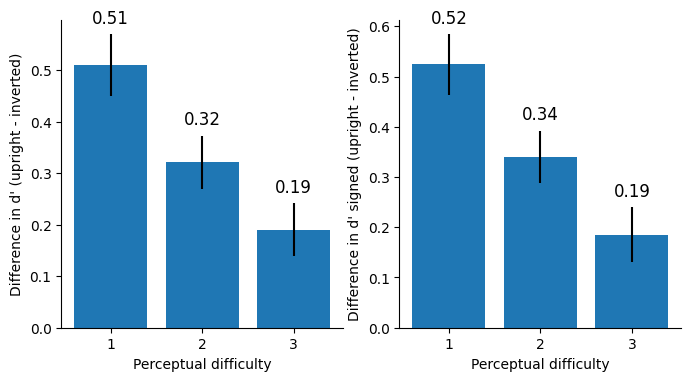

In [9]:
# Plot inversion effect
fig, axs = plt.subplots(1,2, figsize=(8,4))

barplot_inv = axs[0].bar(["1", "2", "3"],
       [
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==1)].groupby(["userID"]).dprime.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==1)].groupby(["userID"]).dprime.mean()).mean(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==2)].groupby(["userID"]).dprime.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==2)].groupby(["userID"]).dprime.mean()).mean(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==3)].groupby(["userID"]).dprime.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==3)].groupby(["userID"]).dprime.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==1)].groupby(["userID"]).dprime.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==1)].groupby(["userID"]).dprime.mean()).sem(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==2)].groupby(["userID"]).dprime.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==2)].groupby(["userID"]).dprime.mean()).sem(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==3)].groupby(["userID"]).dprime.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==3)].groupby(["userID"]).dprime.mean()).sem(),   
            ],           
            
          # color=get_flattened_palette(['delay'])
       )

barplot_inv_dprime_signed = axs[1].bar(["1", "2", "3"],
       [
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()).mean(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()).mean(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()).sem(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()).sem(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()).sem(),   
            ],           
            
          # color=get_flattened_palette(['delay'])
       )

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
axs[0].bar_label(barplot_inv, fmt='%0.2f', padding=5, size=12)
axs[0].set_ylabel("Difference in d' (upright - inverted)")
axs[0].set_xlabel('Perceptual difficulty')

axs[1].bar_label(barplot_inv_dprime_signed, fmt='%0.2f', padding=5, size=12)
axs[1].set_ylabel("Difference in d' signed (upright - inverted)")
axs[1].set_xlabel('Perceptual difficulty')

sns.despine()

plt.show()

In [10]:
# Check with 2 way ANOVA

d = cell.groupby(["userID","inverted","difficulty"]).dprime.mean().reset_index().copy()


aov = pg.anova(data=d, 
               dv='dprime', between=['inverted', 'difficulty'],
             detailed=True)

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov#.round(4)



,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,inverted,12.350518,1,12.350518,67.957671,2.158163e-15,0.139270,***
1,difficulty,9.016799,2,4.508399,24.807084,6.556935e-11,0.105649,***
2,inverted * difficulty,1.837872,2,0.918936,5.056367,6.761886e-03,0.023512,**
3,Residual,76.330123,420,0.181738,NaN,NaN,NaN,


In [11]:
# Post-hoc pairwise comparisons for inverted
posthoc_inverted = pg.pairwise_tukey(data=d, dv='dprime', between='inverted')
posthoc_inverted['star_gazing'] = posthoc_inverted['p-tukey'].apply(star_gazing)
print("Post-hoc comparisons for inverted:")
# print(posthoc_inverted)
display(posthoc_inverted)

# Post-hoc pairwise comparisons for difficulty
posthoc_difficulty = pg.pairwise_tukey(data=d, dv='dprime', between='difficulty', effsize='cohen')
posthoc_difficulty['star_gazing'] = posthoc_difficulty['p-tukey'].apply(star_gazing)
print("\nPost-hoc comparisons for difficulty:")
# print(posthoc_difficulty)
posthoc_difficulty

Post-hoc comparisons for inverted:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,star_gazing
0,False,True,0.856613,0.516073,0.34054,0.04394,7.750061,2.194911e-13,0.749654,***



Post-hoc comparisons for difficulty:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,1,2,0.879488,0.651177,0.228311,0.0549,4.158694,1.146750e-04,0.451209,***
1,1,3,0.879488,0.528365,0.351123,0.0549,6.395722,1.270544e-09,0.739179,***
2,2,3,0.651177,0.528365,0.122812,0.0549,2.237028,6.624330e-02,0.306742,


#### signed d'

In [12]:
# Check with 2 way ANOVA
# d = None
# aov = None

d_dsign = cell.groupby(["userID","inverted","difficulty"]).dprime_signed.mean().reset_index().copy()


aov_dsign = pg.anova(data=d_dsign, 
               dv='dprime_signed', between=['inverted', 'difficulty'],
             detailed=True)

aov_dsign['star_gazing'] = aov_dsign['p-unc'].apply(star_gazing)

aov_dsign#.round(4)



,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,inverted,13.037334,1,13.037334,65.718673,5.749127e-15,0.135302,***
1,difficulty,9.194037,2,4.597018,23.172679,2.842777e-10,0.099380,***
2,inverted * difficulty,2.040229,2,1.020114,5.142199,6.218352e-03,0.023901,**
3,Residual,83.320006,420,0.198381,NaN,NaN,NaN,


In [13]:
# Post-hoc pairwise comparisons for inverted
posthoc_inverted_dsign = pg.pairwise_tukey(data=d_dsign, dv='dprime_signed', between='inverted')
posthoc_inverted_dsign['star_gazing'] = posthoc_inverted_dsign['p-tukey'].apply(star_gazing)
print("Post-hoc comparisons for inverted:")
# print(posthoc_inverted)
display(posthoc_inverted_dsign)

# Post-hoc pairwise comparisons for difficulty
posthoc_difficulty_dsign = pg.pairwise_tukey(data=d_dsign, dv='dprime_signed', between='difficulty', effsize='cohen')
posthoc_difficulty_dsign['star_gazing'] = posthoc_difficulty_dsign['p-tukey'].apply(star_gazing)
print("\nPost-hoc comparisons for difficulty:")
# print(posthoc_difficulty_dsign)
posthoc_difficulty_dsign

Post-hoc comparisons for inverted:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,star_gazing
0,False,True,0.849898,0.500018,0.34988,0.04576,7.646043,2.908784e-13,0.739593,***



Post-hoc comparisons for difficulty:


,A,B,mean(A),mean(B),diff,se,T,p-tukey,cohen,star_gazing
0,1,2,0.870076,0.639206,0.230871,0.057239,4.033443,1.923511e-04,0.439768,***
1,1,3,0.870076,0.515592,0.354484,0.057239,6.193035,4.194682e-09,0.717138,***
2,2,3,0.639206,0.515592,0.123613,0.057239,2.159592,7.946648e-02,0.293064,


#### Plot nicely the results

{'name': 'Arial'}
Inversion effect for Unfilled Delay, N=71
d' for the effect


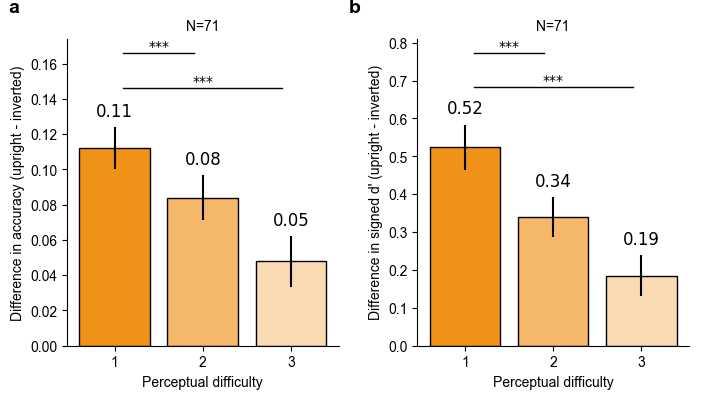

In [14]:
# define canvas

from cand import Canvas, Vector, Point

# reset params just in case
plt.rcdefaults()

# to make all stripplots look the same and avoid the random jitter
# https://stackoverflow.com/questions/61944815/how-to-set-seed-for-jitter-in-seaborn-stripplot
np.random.seed(123)

font_size=14
legend_size=10


# CanD
a = 18
b = 10
# rot = 15
c = Canvas(a, b, "cm")

# set font
c.set_font("Arial", size=10)

# letters
# c.add_text("A)", Point(.02, 0.97), weight="bold", size=font_size)
# c.add_text("A)", Point(.02, 0.97), size=font_size)
c.add_text("a", Point(.02, 0.98), weight="bold", size=font_size)
c.add_text("b", Point(.5, 0.98), weight="bold", size=font_size)
           
# titles
titles = [f"Inversion effect for Unfilled Delay, N={df_dataset6.userID.unique().size}", "d' for the effect"]
# c.add_text(titles[0], Point(.55, 0.97), size=font_size)
for title in titles:
    print(title)


left_offset = 1.7
top_offset = 1
middle = 12
# hspace_between_plots = 2.8
bottom_offset = 1.2

hsb=1
vsb=2

# ### GRID
# # top row
c.add_grid(["inversion_effect", "inversion_effect_dprime_signed"], 1, Point(left_offset, bottom_offset, "cm"), Point(a-.5, b-top_offset, "cm"), spacing=Vector(vsb, hsb, "cm"), unitname="grid")


#### Plot inversion effect
barplot_inv = c.ax("inversion_effect").bar(["1", "2", "3"],
       [
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()).sem(),   
            ],           
            
          color=get_flattened_palette(['delay']), edgecolor='k',
       )

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
c.ax("inversion_effect").bar_label(barplot_inv, fmt='%0.2f', padding=5, size=12)
c.ax("inversion_effect").set_ylabel('Difference in accuracy (upright - inverted)')


## add significance
for idx, row in posthoc_difficulty_acc.iterrows():
    # plot only significant
    if row['p-tukey']<0.05:
        plot_significance_pairs(row['A']-1,#np.where(c.ax(f"d_prime_{i}").get_xticklabels() == row['A'])[0],
                                row['B']-1, 
                                row['p-tukey'], c.ax("inversion_effect"), yerr=True, dh=-0.45, barh=0, x_offset=0.1)

### Plot inversion
barplot_inv_dprime_signed = c.ax("inversion_effect_dprime_signed").bar(["1", "2", "3"],
       [
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()).mean(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()).mean(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==1)].groupby(["userID"]).dprime_signed.mean()).sem(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==2)].groupby(["userID"]).dprime_signed.mean()).sem(),
           #
           (cell[(cell["inverted"]==False)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()-cell[(cell["inverted"]==True)&(cell["difficulty"]==3)].groupby(["userID"]).dprime_signed.mean()).sem(),   
            ],           
            
          color=get_flattened_palette(['delay']), edgecolor='k',
       )


# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
c.ax("inversion_effect_dprime_signed").bar_label(barplot_inv_dprime_signed, fmt='%0.2f', padding=5, size=12)    
c.ax("inversion_effect_dprime_signed").set_ylabel("Difference in signed d' (upright - inverted)")
# c.ax("inversion_effect").set_xlabel('Perceptual difficulty')
# plt.setp(c.ax("inversion_effect").get_xticklabels(), rotation=rot, horizontalalignment='right', size=10)


## add significance
for idx, row in posthoc_difficulty_dsign.iterrows():
    # plot only significant
    if row['p-tukey']<0.05:
        plot_significance_pairs(row['A']-1,#np.where(c.ax(f"d_prime_{i}").get_xticklabels() == row['A'])[0],
                                row['B']-1,
                                row['p-tukey'], c.ax("inversion_effect_dprime_signed"), yerr=True, dh=-0.45, barh=0, x_offset=0.1)



c.ax("inversion_effect").set_title(f"N={df_dataset6.userID.unique().size}")
c.ax("inversion_effect_dprime_signed").set_title(f"N={df_dataset6.userID.unique().size}")

for ax in c.axes.values():
    sns.despine(ax=ax)
    ax.set_xlabel('Perceptual difficulty')


# c.debug_grid(Vector(0.5,0.5,"cm"))
c.show()
#S
# c.save(os.path.join(path_figures, "Fig6", 'SI_Figure_6.png'), dpi=300)#, bbox_inches="tight")
# c.save(os.path.join(path_figures, "Fig6", 'SI_Figure_6.pdf'), dpi=300)#, bbox_inches="tight")

### RT

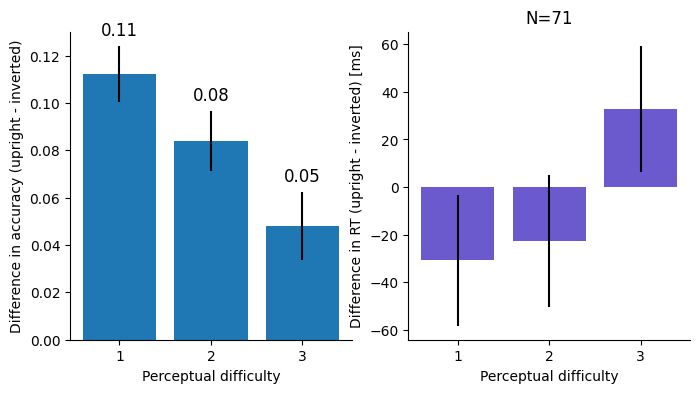

In [15]:
# Plot inversion effect
fig, axs = plt.subplots(1,2, figsize=(8,4))

barplot_inv = axs[0].bar(["1", "2", "3"],
       [
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()).mean(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==36)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==30)].groupby(["userID"]).correct_flt.mean()).sem(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==24)].groupby(["userID"]).correct_flt.mean()).sem(),   
            ],           
            
          # color=get_flattened_palette(['delay'])
       )

barplot_inv_RT = axs[1].bar(["1", "2", "3"],
       [
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==36)].groupby(["userID"]).RT.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==36)].groupby(["userID"]).RT.mean()).mean(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==30)].groupby(["userID"]).RT.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==30)].groupby(["userID"]).RT.mean()).mean(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==24)].groupby(["userID"]).RT.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==24)].groupby(["userID"]).RT.mean()).mean(),

       ],
        # plot SEM
            yerr=[
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==36)].groupby(["userID"]).RT.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==36)].groupby(["userID"]).RT.mean()).sem(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==30)].groupby(["userID"]).RT.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==30)].groupby(["userID"]).RT.mean()).sem(),
           #
           (df_dataset6[(df_dataset6["inverted"]==False)&(df_dataset6["levels"]==24)].groupby(["userID"]).RT.mean()-df_dataset6[(df_dataset6["inverted"]==True)&(df_dataset6["levels"]==24)].groupby(["userID"]).RT.mean()).sem(),   
            ],           
            
          # color=get_flattened_palette(['delay'])
                            color='slateblue'
       )

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
axs[0].bar_label(barplot_inv, fmt='%0.2f', padding=5, size=12)   
axs[0].set_ylabel('Difference in accuracy (upright - inverted)')
axs[0].set_xlabel('Perceptual difficulty')

axs[1].set_ylabel('Difference in RT (upright - inverted) [ms]')
axs[1].set_xlabel('Perceptual difficulty')
axs[1].set_title(f"N={df_dataset6.userID.unique().size}")

sns.despine()

plt.show()

In [16]:
# Check with 2 way ANOVA

d_RT = df_dataset6.groupby(["userID","inverted","difficulty"]).RT.mean().reset_index().copy()


aov = pg.anova(data=d_RT, 
               dv='RT', between=['inverted', 'difficulty'],
             detailed=True)

aov['star_gazing'] = aov['p-unc'].apply(star_gazing)

aov#.round(4)

,Source,SS,DF,MS,F,p-unc,np2,star_gazing
0,inverted,5.010722e+03,1,5010.722277,0.035653,0.850325,0.000085,
1,difficulty,5.723215e+05,2,286160.758715,2.036140,0.131818,0.009603,
2,inverted * difficulty,8.553861e+04,2,42769.304814,0.304319,0.737788,0.001447,
3,Residual,5.902714e+07,420,140540.811047,NaN,NaN,NaN,


In [17]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv

Author: Jan Kadlec

Last updated: Thu Nov 27 2025

Python implementation: CPython
Python version       : 3.8.6
IPython version      : 8.12.3

Compiler    : Clang 6.0 (clang-600.0.57)
OS          : Darwin
Release     : 25.1.0
Machine     : x86_64
Processor   : i386
CPU cores   : 16
Architecture: 64bit

pingouin  : 0.5.5
seaborn   : 0.13.2
sys       : 3.8.6 (v3.8.6:db455296be, Sep 23 2020, 13:31:39) 
[Clang 6.0 (clang-600.0.57)]
pandas    : 2.0.3
matplotlib: 3.7.5
numpy     : 1.24.4
cand      : 0.0.2
scipy     : 1.10.1



[top](#top)